# Assignment 1 (AM5920) - Kanak Agarwal

## Question 1

Choose your favorite function y = f(x), sample M data points from it in a domain and add some noise. This becomes your input paired dataset (\{xi, yi)\}, 1 ≤i ≤M. Use this dataset to construct a linear regression model. Investigate the convergence of your regression. Justify your choice of parameters in the algorithm, such as depth, width of the network?

In [38]:
# Import Necessary Modules
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

In [39]:
# Simple Linear regression model for f(x, y) = sin x^{3} + y^{2}

def generate_data(num_points, noise_std=0.7):
    # Generate random x and y values
    x_values = np.sort(np.random.uniform(0, 2 * np.pi, num_points))
    y_values = np.sort(np.random.uniform(0, 2 * np.pi, num_points))
    # Generate corresponding z values for the function with added noise
    z_values = np.sin(x_values**3) + y_values**2 + np.random.normal(0, noise_std, num_points)
    return x_values, y_values, z_values

data = generate_data(100)

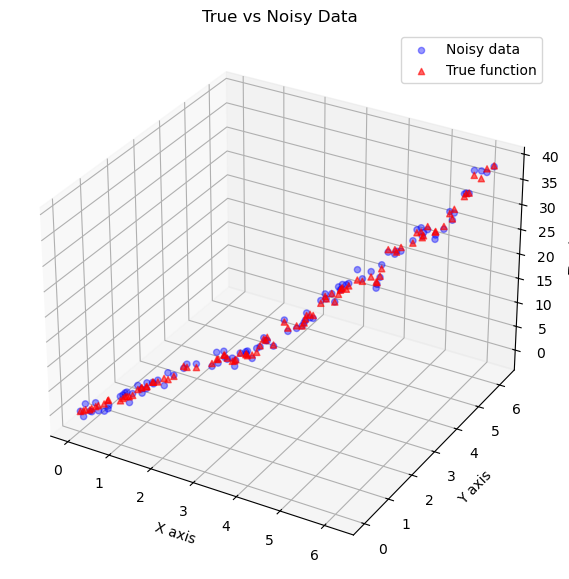

In [40]:
# Plot the generated data
x_values, y_values, z_values = data
z_true = np.sin(x_values**3) + y_values**2

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# noisy data
ax.scatter(x_values, y_values, z_values,
           c='blue', marker='o', alpha=0.4, label='Noisy data')

# true data
ax.scatter(x_values, y_values, z_true,
           c='red', marker='^', alpha=0.6, label='True function')

ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Z axis')
ax.set_title('True vs Noisy Data')
ax.legend()
plt.show()

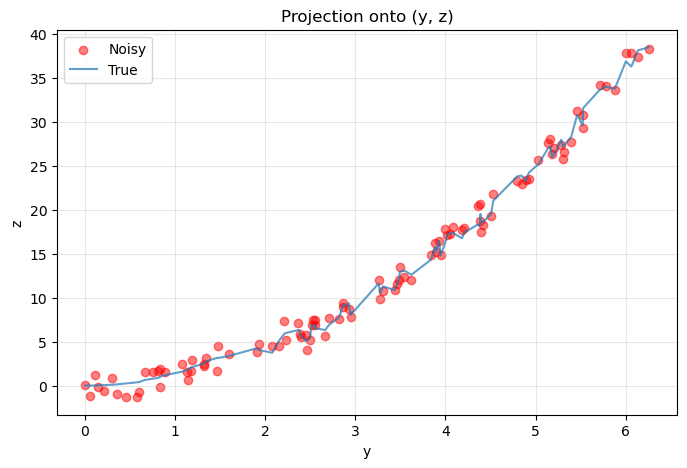

In [41]:
plt.figure(figsize=(8,5))
plt.scatter(y_values, z_values, color='red', alpha=0.5, label='Noisy')
plt.plot(y_values, z_true, alpha=0.7, label='True')

plt.xlabel('y')
plt.ylabel('z')
plt.title('Projection onto (y, z)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [52]:
# Prepare data for training
X = np.column_stack((x_values, y_values))
y = z_values
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

def train(model, optimizer, criterion, inputs, targets):
    def closure():
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        return loss

    optimizer.step(closure)
    return closure().item()

# Define a simple linear regression model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(2, 1)  # Input: (x, y), Output: z

    def forward(self, x):
        return self.linear(x)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

X_tensor = X_tensor.to(device)
y_tensor = y_tensor.to(device)

# Initialize the model, loss function, and optimizer
model = LinearRegressionModel()
model = LinearRegressionModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the model
num_epochs = 10000
l = []
for epoch in range(num_epochs):
    loss = train(model, optimizer, criterion, X_tensor, y_tensor)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}')

    l.append(loss)

Using device: NVIDIA GeForce RTX 3060 Laptop GPU
Epoch [100/10000], Loss: 141.1860
Epoch [200/10000], Loss: 55.8079
Epoch [300/10000], Loss: 29.8938
Epoch [400/10000], Loss: 23.6791
Epoch [500/10000], Loss: 21.7763
Epoch [600/10000], Loss: 20.4821
Epoch [700/10000], Loss: 19.2495
Epoch [800/10000], Loss: 18.0452
Epoch [900/10000], Loss: 16.8858
Epoch [1000/10000], Loss: 15.7868
Epoch [1100/10000], Loss: 14.7601
Epoch [1200/10000], Loss: 13.8135
Epoch [1300/10000], Loss: 12.9519
Epoch [1400/10000], Loss: 12.1773
Epoch [1500/10000], Loss: 11.4895
Epoch [1600/10000], Loss: 10.8862
Epoch [1700/10000], Loss: 10.3634
Epoch [1800/10000], Loss: 9.9160
Epoch [1900/10000], Loss: 9.5381
Epoch [2000/10000], Loss: 9.2232
Epoch [2100/10000], Loss: 8.9642
Epoch [2200/10000], Loss: 8.7543
Epoch [2300/10000], Loss: 8.5866
Epoch [2400/10000], Loss: 8.4547
Epoch [2500/10000], Loss: 8.3526
Epoch [2600/10000], Loss: 8.2748
Epoch [2700/10000], Loss: 8.2165
Epoch [2800/10000], Loss: 8.1735
Epoch [2900/10000]

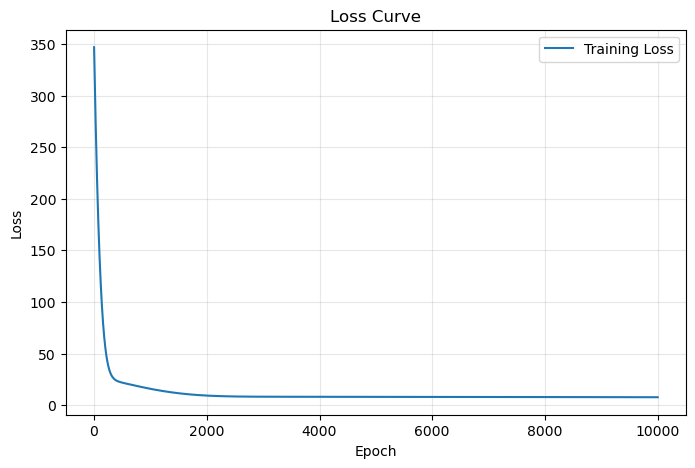

In [53]:
# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs + 1), l, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

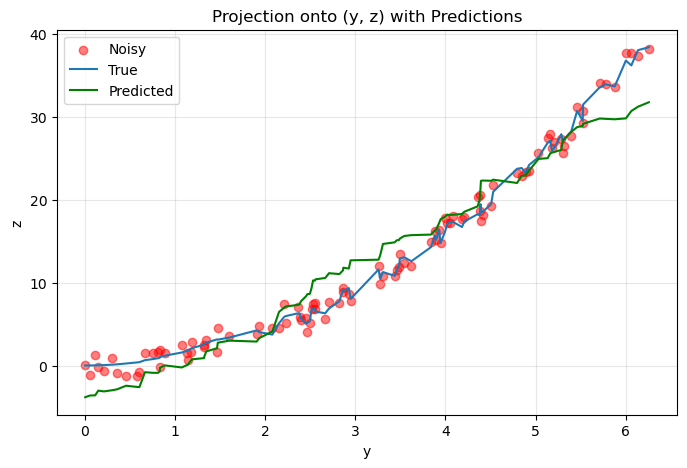

Final Loss: 7.600564002990723


In [47]:
# Plot the fitted data vs true data projection onto (y, z)
model.eval()
with torch.no_grad():
    predicted = model(X_tensor).cpu().numpy()
plt.figure(figsize=(8,5))
plt.scatter(y_values, z_values, color='red',alpha=0.5, label='Noisy')
plt.plot(y_values, z_true, label='True')  
plt.plot(y_values, predicted, color='green', label='Predicted')
plt.xlabel('y')
plt.ylabel('z')
plt.title('Projection onto (y, z) with Predictions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final Loss:", l[-1])

## Question 2

For the function chosen above and using the dataset same as above, construct a simple deep neural network for the supervised learning/regression. Investigate the convergence of your algorithm. Justify your choice of parameters in the algorithm, such as depth, width of the network.

In [ ]:
class FlexibleNN(nn.Module):
    def __init__(self, input_size=1, hidden_layers=[10], output_size=1, activation=nn.ReLU):
        """
        input_size: number of input features
        hidden_layers: list -> neurons in each hidden layer
                       example: [20, 30, 10] → 3 hidden layers
        output_size: number of outputs
        activation: activation class (nn.ReLU, nn.SiLU, nn.Tanh etc.)
        """
        super(FlexibleNN, self).__init__()

        layers = []
        in_features = input_size

        # hidden layers
        for h in hidden_layers:
            layers.append(nn.Linear(in_features, h))
            layers.append(activation())
            in_features = h

        # output layer
        layers.append(nn.Linear(in_features, output_size))

        # pack into Sequential
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)
    
model = FlexibleNN(input_size=2, hidden_layers=[10, 10], output_size=1)
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the flexible model
num_epochs = 10000
l = []
for epoch in range(num_epochs):
    loss = train(model, optimizer, criterion, X_tensor, y_tensor)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}')

    l.append(loss)

Epoch [100/10000], Loss: 7.6147
Epoch [200/10000], Loss: 2.1770
Epoch [300/10000], Loss: 1.9341
Epoch [400/10000], Loss: 1.7858
Epoch [500/10000], Loss: 1.5455
Epoch [600/10000], Loss: 1.2073
Epoch [700/10000], Loss: 1.0698
Epoch [800/10000], Loss: 0.9790
Epoch [900/10000], Loss: 0.9385
Epoch [1000/10000], Loss: 0.9151
Epoch [1100/10000], Loss: 0.8982
Epoch [1200/10000], Loss: 0.8861
Epoch [1300/10000], Loss: 0.8770
Epoch [1400/10000], Loss: 0.8696
Epoch [1500/10000], Loss: 0.8631
Epoch [1600/10000], Loss: 0.8571
Epoch [1700/10000], Loss: 0.8514
Epoch [1800/10000], Loss: 0.8464
Epoch [1900/10000], Loss: 0.8416
Epoch [2000/10000], Loss: 0.8390
Epoch [2100/10000], Loss: 0.8363
Epoch [2200/10000], Loss: 0.8346
Epoch [2300/10000], Loss: 0.8350
Epoch [2400/10000], Loss: 0.8338
Epoch [2500/10000], Loss: 0.8327
Epoch [2600/10000], Loss: 0.8334
Epoch [2700/10000], Loss: 0.8325
Epoch [2800/10000], Loss: 0.8339
Epoch [2900/10000], Loss: 0.8319
Epoch [3000/10000], Loss: 0.8322
Epoch [3100/10000],

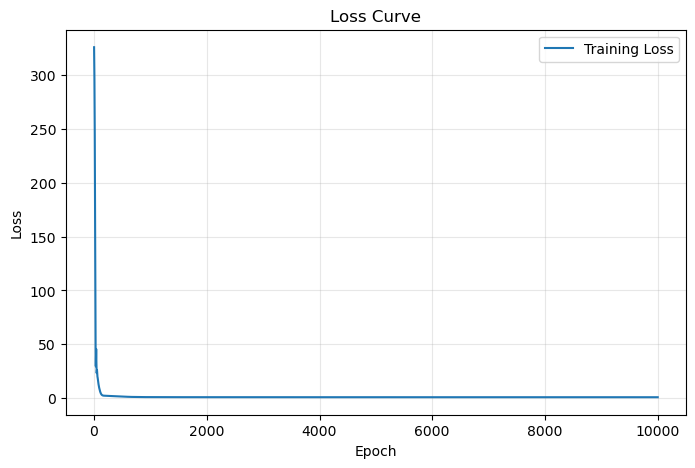

In [9]:
# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs + 1), l, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

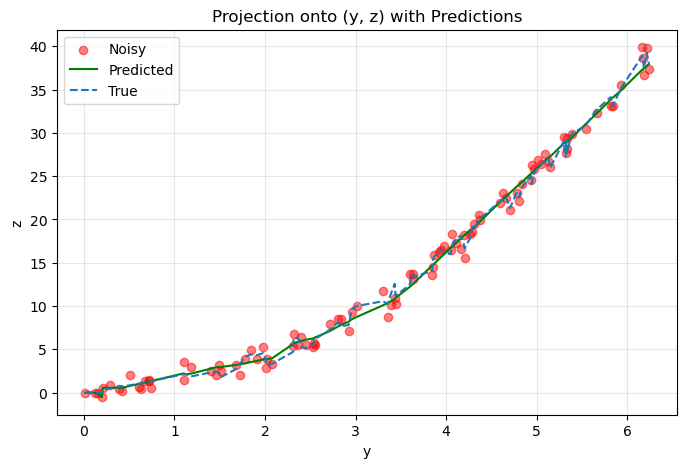

Final Loss: 0.8195960521697998


In [10]:
# Plot the fitted data vs true data projection onto (y, z)
model.eval()
with torch.no_grad():
    predicted = model(X_tensor).cpu().numpy()
plt.figure(figsize=(8,5))
plt.scatter(y_values, z_values, color='red',alpha=0.5, label='Noisy') 
plt.plot(y_values, predicted, color='green', label='Predicted')
plt.plot(y_values, z_true, label='True', linestyle='--') 
plt.xlabel('y')
plt.ylabel('z')
plt.title('Projection onto (y, z) with Predictions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final Loss:", l[-1])

In [54]:
# Changing the Depth of the hidden layers

model = FlexibleNN(input_size=2, hidden_layers=[2,2,2,2,2,2,2,2,2,2], output_size=1)
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Train the flexible model
num_epochs = 10000
l = []
for epoch in range(num_epochs):
    loss = train(model, optimizer, criterion, X_tensor, y_tensor)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}')

    l.append(loss)

Epoch [100/10000], Loss: 122.6920
Epoch [200/10000], Loss: 122.5273
Epoch [300/10000], Loss: 122.5273
Epoch [400/10000], Loss: 122.5273
Epoch [500/10000], Loss: 122.5273
Epoch [600/10000], Loss: 122.5273
Epoch [700/10000], Loss: 122.5273
Epoch [800/10000], Loss: 122.5273
Epoch [900/10000], Loss: 122.5273
Epoch [1000/10000], Loss: 122.5273
Epoch [1100/10000], Loss: 122.5273
Epoch [1200/10000], Loss: 122.5273
Epoch [1300/10000], Loss: 122.5273
Epoch [1400/10000], Loss: 122.5273
Epoch [1500/10000], Loss: 122.5273
Epoch [1600/10000], Loss: 122.5273
Epoch [1700/10000], Loss: 122.5273
Epoch [1800/10000], Loss: 122.5273
Epoch [1900/10000], Loss: 122.5273
Epoch [2000/10000], Loss: 122.5273
Epoch [2100/10000], Loss: 122.5273
Epoch [2200/10000], Loss: 122.5273
Epoch [2300/10000], Loss: 122.5273
Epoch [2400/10000], Loss: 122.5273
Epoch [2500/10000], Loss: 122.5273
Epoch [2600/10000], Loss: 122.5273
Epoch [2700/10000], Loss: 122.5273
Epoch [2800/10000], Loss: 122.5273
Epoch [2900/10000], Loss: 122

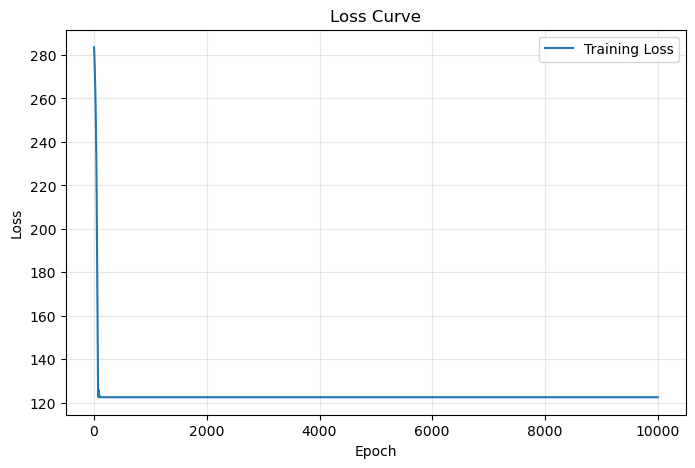

In [55]:
# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs + 1), l, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

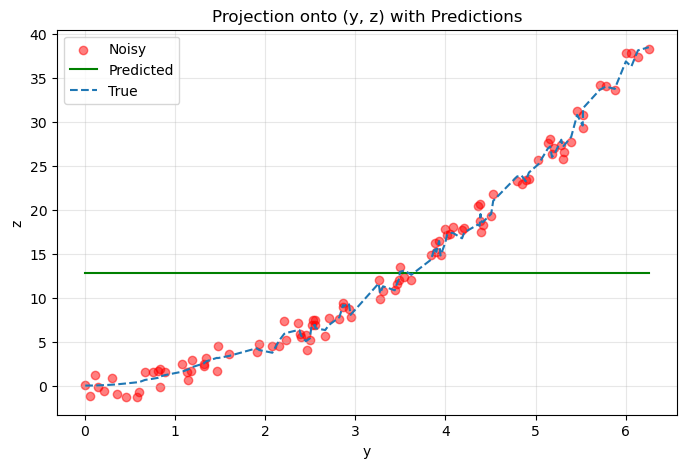

Final Loss: 122.52734375


In [56]:
# Plot the fitted data vs true data projection onto (y, z)
model.eval()
with torch.no_grad():
    predicted = model(X_tensor).cpu().numpy()
plt.figure(figsize=(8,5))
plt.scatter(y_values, z_values, color='red',alpha=0.5, label='Noisy') 
plt.plot(y_values, predicted, color='green', label='Predicted')
plt.plot(y_values, z_true, label='True', linestyle='--') 
plt.xlabel('y')
plt.ylabel('z')
plt.title('Projection onto (y, z) with Predictions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final Loss:", l[-1])

## Question 3

For the function chosen above and using the dataset same as above, construct a ResNet. Investigate the convergence of your algorithm. Justify your choice of parameters in the algorithm, such as depth, width of the network. Comment on generalisability of the network.

In [ ]:
# Implementing a resNet on the same data

class ResNetBlock(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(ResNetBlock, self).__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        residual = x
        out = self.linear1(x)
        out = self.activation(out)
        out = self.linear2(out)
        return out + residual
    
class ResNet(nn.Module):
    def __init__(self, input_size=2, hidden_size=10, num_blocks=3, output_size=1):
        super(ResNet, self).__init__()
        self.blocks = nn.ModuleList([ResNetBlock(input_size, hidden_size) for _ in range(num_blocks)])
        self.output_layer = nn.Linear(input_size, output_size)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.output_layer(x)
    
model = ResNet(input_size=2, hidden_size=3, num_blocks=100, output_size=1)
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
# Train the ResNet model
num_epochs = 10000
l = []
for epoch in range(num_epochs): 
    loss = train(model, optimizer, criterion, X_tensor, y_tensor)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss:.4f}')

    l.append(loss)

Epoch [100/10000], Loss: 1.4980
Epoch [200/10000], Loss: 1.1304
Epoch [300/10000], Loss: 0.8932
Epoch [400/10000], Loss: 1.7208
Epoch [500/10000], Loss: 2.1457
Epoch [600/10000], Loss: 0.8572
Epoch [700/10000], Loss: 0.9263
Epoch [800/10000], Loss: 0.9109
Epoch [900/10000], Loss: 0.7697
Epoch [1000/10000], Loss: 1.1875
Epoch [1100/10000], Loss: 1.1550
Epoch [1200/10000], Loss: 0.7980
Epoch [1300/10000], Loss: 0.9134
Epoch [1400/10000], Loss: 0.7067
Epoch [1500/10000], Loss: 0.8354
Epoch [1600/10000], Loss: 0.7064
Epoch [1700/10000], Loss: 0.8139
Epoch [1800/10000], Loss: 0.9709
Epoch [1900/10000], Loss: 0.8422
Epoch [2000/10000], Loss: 0.9690
Epoch [2100/10000], Loss: 0.7049
Epoch [2200/10000], Loss: 1.3161
Epoch [2300/10000], Loss: 0.7648
Epoch [2400/10000], Loss: 0.7620
Epoch [2500/10000], Loss: 0.9532
Epoch [2600/10000], Loss: 0.7249
Epoch [2700/10000], Loss: 0.7863
Epoch [2800/10000], Loss: 0.7552
Epoch [2900/10000], Loss: 0.7446
Epoch [3000/10000], Loss: 0.8586
Epoch [3100/10000],

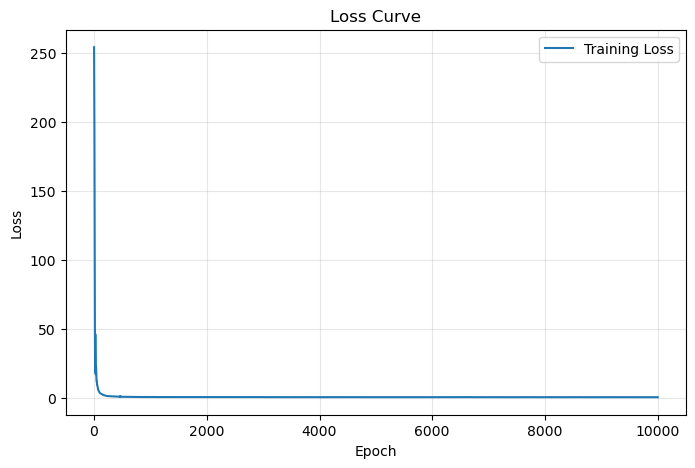

In [73]:
# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs + 1), l, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

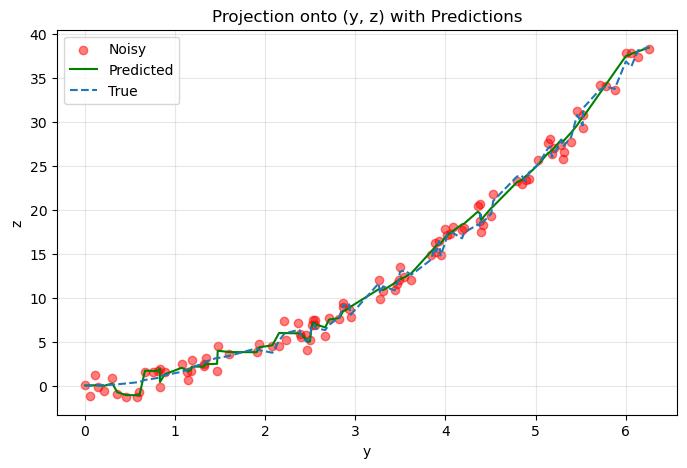

Final Loss: 0.5943590402603149


In [78]:
# Plot the fitted data vs true data projection onto (y, z)
model.eval()
with torch.no_grad():
    predicted = model(X_tensor).cpu().numpy()
plt.figure(figsize=(8,5))
plt.scatter(y_values, z_values, color='red',alpha=0.5, label='Noisy') 
plt.plot(y_values, predicted, color='green', label='Predicted')
plt.plot(y_values, z_true, label='True', linestyle='--') 
plt.xlabel('y')
plt.ylabel('z')
plt.title('Projection onto (y, z) with Predictions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Final Loss:", l[-1])